In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iklim_harian_sleman_2022-2024.xlsx to iklim_harian_sleman_2022-2024.xlsx


In [ ]:
df = pd.read_excel("iklim_harian_sleman_2022-2024.xlsx", na_values=[" ", "-", "NA", "N/A", "NaN", "null"])
df['DDD_CAR'] = df['DDD_CAR'].str.strip().str.upper()
df.head(10)

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,01-01-2022,24.0,31.6,26.2,88.0,0.0,5.4,2,200.0,1,C
1,02-01-2022,23.2,30.3,26.4,88.0,87.5,4.0,3,260.0,2,S
2,03-01-2022,24.0,32.0,27.0,83.0,0.0,5.1,2,200.0,2,S
3,04-01-2022,21.0,31.9,26.0,82.0,0.0,4.8,4,210.0,2,SW
4,05-01-2022,23.2,32.1,26.9,80.0,0.0,10.0,4,180.0,2,SW
5,06-01-2022,22.8,32.2,26.7,80.0,NaN,9.8,2,180.0,1,S
6,07-01-2022,23.6,32.6,27.0,82.0,NaN,6.0,3,260.0,2,S
7,08-01-2022,22.4,32.6,26.9,83.0,10.6,8.3,2,220.0,1,C
8,09-01-2022,22.8,30.4,26.1,91.0,12.0,6.3,2,220.0,1,C
9,10-01-2022,NaN,32.0,26.3,86.0,37.6,0.4,3,260.0,1,C


**EDA**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TANGGAL  1096 non-null   object 
 1   TN       1088 non-null   float64
 2   TX       1090 non-null   float64
 3   TAVG     1095 non-null   float64
 4   RH_AVG   1095 non-null   float64
 5   RR       1034 non-null   float64
 6   SS       1092 non-null   float64
 7   FF_X     1096 non-null   int64  
 8   DDD_X    1095 non-null   float64
 9   FF_AVG   1096 non-null   int64  
 10  DDD_CAR  1096 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 94.3+ KB


In [ ]:
df.describe()

,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
count,1088.000000,1090.000000,1095.000000,1095.000000,1034.000000,1092.000000,1096.000000,1095.000000,1096.000000
mean,23.305055,31.723853,26.916256,84.577169,487.332689,5.716758,3.482664,204.315982,1.643248
std,1.353255,1.360744,1.573004,5.383741,2011.215785,2.802324,1.021982,53.121731,0.690119
min,18.000000,26.200000,22.900000,66.000000,0.000000,0.000000,1.000000,10.000000,0.000000
25%,22.800000,31.000000,25.800000,81.000000,0.000000,3.600000,3.000000,180.000000,1.000000
50%,23.600000,31.800000,26.600000,85.000000,0.000000,6.200000,3.500000,200.000000,2.000000
75%,24.200000,32.600000,27.900000,88.000000,8.775000,8.000000,4.000000,240.000000,2.000000
max,26.400000,36.300000,31.500000,98.000000,8888.000000,10.400000,8.000000,360.000000,4.000000


In [ ]:
#Cek missing value
df.isnull().sum()

,0
TANGGAL,0
TN,8
TX,6
TAVG,1
RH_AVG,1
RR,62
SS,4
FF_X,0
DDD_X,1
FF_AVG,0


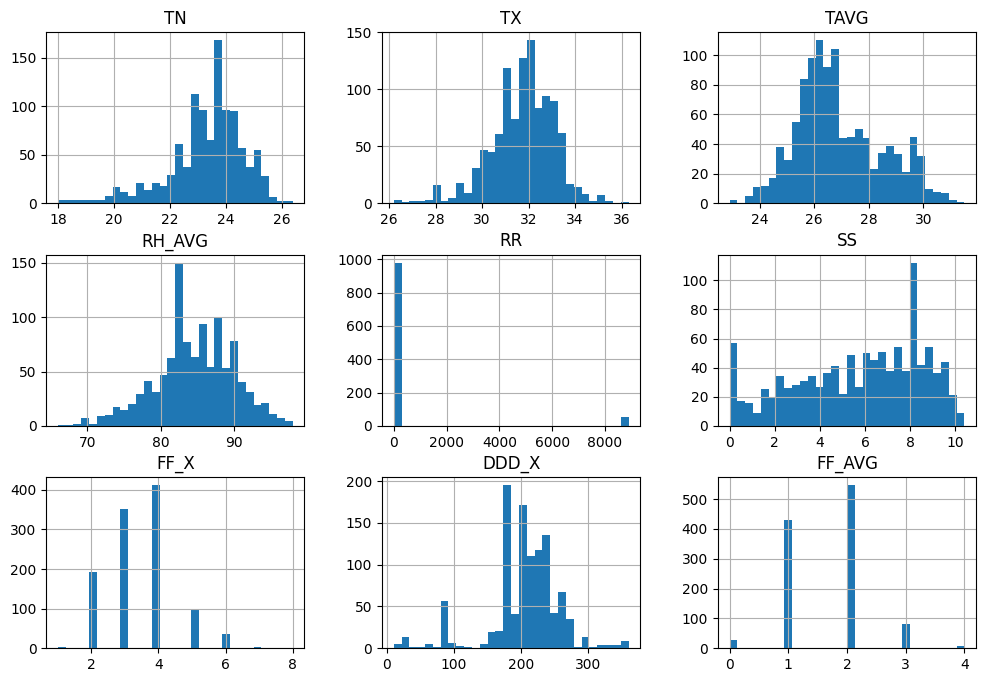

In [ ]:
#Visualisasi Distribusi Data (Numerik)
import matplotlib.pyplot as plt
df.hist(figsize=(12, 8), bins=30)
plt.show()

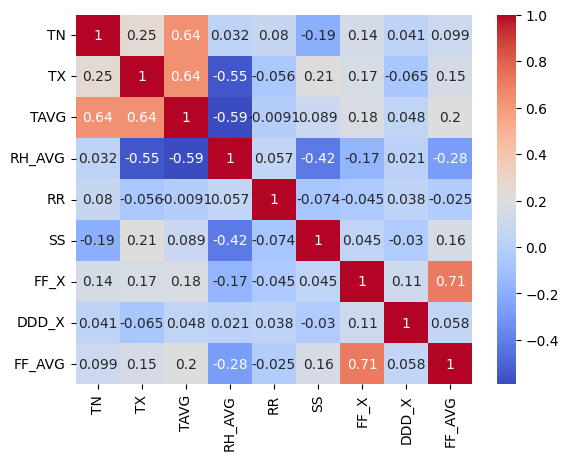

In [ ]:
#Visualisasi Korelasi Antarfitur (Numerik)
import seaborn as sns
df_numeric = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

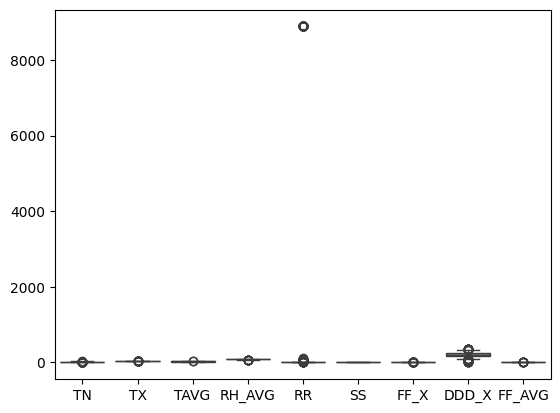

In [ ]:
#Cek Outlier
import seaborn as sns
import matplotlib.pyplot as plt
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.boxplot(data=df[numerical_cols])
plt.show()

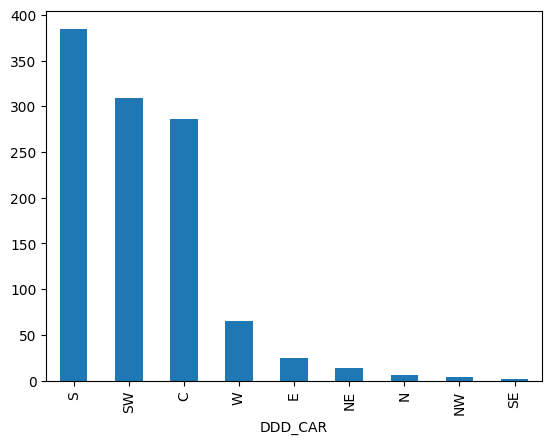

In [ ]:
#cek distribusi data kategorikal
df['DDD_CAR'].value_counts().plot(kind='bar')
plt.show()

**Preprocessing Data**

In [ ]:
df[df['RR'] > 8000]

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
29,30-01-2022,24.3,32.0,27.5,82.0,8888.0,7.7,4,210.0,3,SW
38,08-02-2022,23.4,33.0,27.0,86.0,8888.0,0.0,2,80.0,1,C
39,09-02-2022,24.0,32.2,26.9,86.0,8888.0,2.2,4,240.0,2,SW
42,12-02-2022,23.7,33.0,27.1,82.0,8888.0,3.1,2,200.0,2,SW
43,13-02-2022,24.0,30.6,25.4,86.0,8888.0,7.5,3,180.0,1,C
50,20-02-2022,23.8,30.2,26.4,89.0,8888.0,3.1,3,240.0,2,SW
51,21-02-2022,22.4,31.0,26.3,86.0,8888.0,0.2,3,240.0,2,S
98,09-04-2022,23.2,31.0,26.3,88.0,8888.0,5.4,2,180.0,1,S
104,15-04-2022,23.4,NaN,27.3,85.0,8888.0,8.4,4,210.0,2,C
113,24-04-2022,22.6,33.2,26.5,88.0,8888.0,7.5,2,320.0,1,C


In [ ]:
df.loc[df['RR'] > 8000, 'RR'] = 0

In [ ]:
#penanganan missing value
df['TN'] = df['TN'].fillna(df['TN'].mean())
df['TX'] = df['TX'].fillna(df['TX'].mean())
df['TAVG'] = df['TAVG'].fillna(df['TAVG'].mean())
df['RH_AVG'] = df['RH_AVG'].fillna(df['RH_AVG'].mean())
df['RR'] = df['RR'].fillna(df['RR'].mean())
df['SS'] = df['SS'].fillna(df['SS'].mean())
df['FF_X'] = df['FF_X'].fillna(df['FF_X'].mean())
df['DDD_X'] = df['DDD_X'].fillna(df['DDD_X'].mean())
df['FF_AVG'] = df['FF_AVG'].fillna(df['FF_AVG'].mean())

df.isnull().sum()

,0
TANGGAL,0
TN,0
TX,0
TAVG,0
RH_AVG,0
RR,0
SS,0
FF_X,0
DDD_X,0
FF_AVG,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['DDD_CAR']])
# memasukkan kembali ke df
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['DDD_CAR']))
df = pd.concat([df.drop('DDD_CAR', axis=1), encoded_df], axis=1)


In [ ]:
df.columns


Index(['TANGGAL', 'TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X',
       'FF_AVG', 'DDD_CAR_C', 'DDD_CAR_E', 'DDD_CAR_N', 'DDD_CAR_NE',
       'DDD_CAR_NW', 'DDD_CAR_S', 'DDD_CAR_SE', 'DDD_CAR_SW', 'DDD_CAR_W'],
      dtype='object')

In [ ]:
#penanganan outlier
import numpy as np

#mengambil kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

#winsorizing berbasis IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))


In [ ]:
#Menampilkan hasil penanganan outlier
import pandas as pd
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    #menghitung outlier
    lower_outliers = (df[col] < lower).sum()
    upper_outliers = (df[col] > upper).sum()
    total_outliers = lower_outliers + upper_outliers

    outlier_counts[col] = {
        'Lower Outliers': lower_outliers,
        'Upper Outliers': upper_outliers,
        'Total Outliers': total_outliers
    }
pd.DataFrame(outlier_counts).T


,Lower Outliers,Upper Outliers,Total Outliers
TN,0,0,0
TX,0,0,0
TAVG,0,0,0
RH_AVG,0,0,0
RR,0,0,0
SS,0,0,0
FF_X,0,0,0
DDD_X,0,0,0
FF_AVG,0,0,0
DDD_CAR_C,0,0,0


In [ ]:
#Fitur Selection
X = df[['TN', 'TX','TAVG','RH_AVG','FF_AVG', 'SS', 'DDD_CAR_C', 'DDD_CAR_E', 'DDD_CAR_N', 'DDD_CAR_NE', 'DDD_CAR_NW', 'DDD_CAR_S', 'DDD_CAR_SE', 'DDD_CAR_SW', 'DDD_CAR_W']]
Y = df['RR']
X.head(), Y.head()


(     TN    TX  TAVG  RH_AVG  FF_AVG    SS  DDD_CAR_C  DDD_CAR_E  DDD_CAR_N  \
 0  24.0  31.6  26.2    88.0     1.0   5.4        1.0        0.0        0.0   
 1  23.2  30.3  26.4    88.0     2.0   4.0        0.0        0.0        0.0   
 2  24.0  32.0  27.0    83.0     2.0   5.1        0.0        0.0        0.0   
 3  21.0  31.9  26.0    82.0     2.0   4.8        0.0        0.0        0.0   
 4  23.2  32.1  26.9    80.0     2.0  10.0        0.0        0.0        0.0   
 
    DDD_CAR_NE  DDD_CAR_NW  DDD_CAR_S  DDD_CAR_SE  DDD_CAR_SW  DDD_CAR_W  
 0         0.0         0.0        0.0         0.0         0.0        0.0  
 1         0.0         0.0        1.0         0.0         0.0        0.0  
 2         0.0         0.0        1.0         0.0         0.0        0.0  
 3         0.0         0.0        0.0         0.0         1.0        0.0  
 4         0.0         0.0        0.0         0.0         1.0        0.0  ,
 0     0.000000
 1    14.927466
 2     0.000000
 3     0.000000
 4     0.

In [ ]:
#Buat label Klasifikasi
def classify_rr(value):
    if value == 0:
        return 0  #Tidak Hujan
    elif value <= 5:
        return 1  #Light Rain
    else:
        return 2  #Rain

In [ ]:
def one_hot_encode(label):
    if label == 0:
        return [1, 0, 0]
    elif label == 1:
        return [0, 1, 0]
    else:
        return [0, 0, 1]


In [ ]:
df["class_label"] = df["RR"].apply(classify_rr)
df["class_onehot"] = df["class_label"].apply(one_hot_encode)


/tmp/ipython-input-883921354.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["class_label"], palette="viridis")


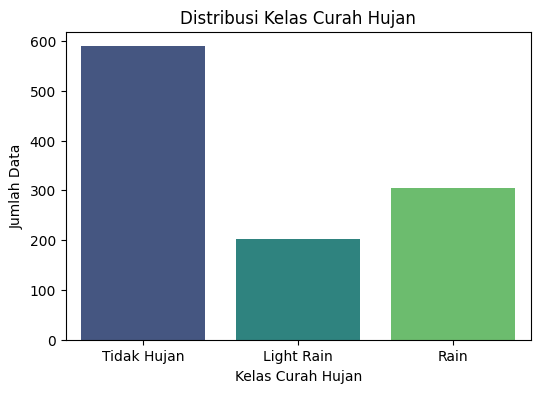

In [ ]:
# Visualisasi

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=df["class_label"], palette="viridis")

plt.xticks([0,1,2], ["Tidak Hujan", "Light Rain", "Rain"])
plt.xlabel("Kelas Curah Hujan")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Kelas Curah Hujan")
plt.show()




In [ ]:
#Membuat label fitur baru
X = df[['TN', 'TX','TAVG','RH_AVG','FF_AVG', 'SS',
        'DDD_CAR_C', 'DDD_CAR_E', 'DDD_CAR_N', 'DDD_CAR_NE',
        'DDD_CAR_NW', 'DDD_CAR_S', 'DDD_CAR_SE', 'DDD_CAR_SW', 'DDD_CAR_W']]

y = df["class_label"]

In [ ]:
#Normalisasi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#Pembentukan data sequence
def create_sequences(X, y, timesteps=25):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)


In [ ]:
#Mengecek shape data
X_seq, y_seq = create_sequences(X_scaled, y, timesteps=25)

print(X_seq.shape)
print(y_seq.shape)


(1071, 25, 15)
(1071,)


In [ ]:
#Splitting data
from sklearn.model_selection import train_test_split
X_train_rnn, X_test_rnn, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False )


**Pemodelan**

In [ ]:
#Model RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model_rnn = Sequential([
    SimpleRNN(128, return_sequences=False, input_shape=(20, 15)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(3, activation='softmax')
])

model_rnn.compile(
    optimizer=Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3577 - loss: 1.1456 - val_accuracy: 0.4884 - val_loss: 1.0158
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4773 - loss: 1.0134 - val_accuracy: 0.5349 - val_loss: 0.9803
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5507 - loss: 0.9405 - val_accuracy: 0.5640 - val_loss: 0.9359
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5297 - loss: 0.9288 - val_accuracy: 0.5349 - val_loss: 0.9490
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5633 - loss: 0.8929 - val_accuracy: 0.4186 - val_loss: 1.0672
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5805 - loss: 0.8705 - val_accuracy: 0.5349 - val_loss: 0.9677
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5966 - loss: 0.8770 - val_accuracy: 0.4477 - val_loss: 1.0497
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5869 - loss: 0.8470 - val_accuracy: 0.5116 - val_l

In [ ]:
#Model LSTM
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(20, 15)),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_rnn, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.4304 - loss: 1.0459 - val_accuracy: 0.5349 - val_loss: 1.0279
Epoch 2/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5371 - loss: 0.9777 - val_accuracy: 0.4360 - val_loss: 1.0587
Epoch 3/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5823 - loss: 0.9123 - val_accuracy: 0.4593 - val_loss: 1.0292
Epoch 4/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5494 - loss: 0.9162 - val_accuracy: 0.5000 - val_loss: 1.0180
Epoch 5/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5387 - loss: 0.9224 - val_accuracy: 0.4360 - val_loss: 1.0583
Epoch 6/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5501 - loss: 0.8996 - val_accuracy: 0.4302 - val_loss: 1.0513
Epoch 7/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5349 - loss: 0.9022 - val_accuracy: 0.3837 - val_loss: 1.0795
Epoch 8/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5934 - loss: 0.8718 - val_accuracy: 0

**Evaluasi**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rnn = model_rnn.predict(X_test_rnn).argmax(axis=1)
print("Akurasi RNN:", accuracy_score(y_test, y_pred_rnn))
print("=== Classification Report RNN ===")
print(classification_report(y_test, y_pred_rnn))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Akurasi RNN: 0.7534883720930232
=== Classification Report RNN ===
              precision    recall  f1-score   support

           0       0.78      0.97      0.87       145
           1       0.00      0.00      0.00        26
           2       0.62      0.48      0.54        44

    accuracy                           0.75       215
   macro avg       0.47      0.48      0.47       215
weighted avg       0.65      0.75      0.69       215



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred_lstm = model_lstm.predict(X_test_rnn).argmax(axis=1)
print("Akurasi LSTM:", accuracy_score(y_test, y_pred_lstm))
print("=== Classification Report LSTM ===")
print(classification_report(y_test, y_pred_lstm))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
Akurasi LSTM: 0.7162790697674418
=== Classification Report LSTM ===
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       145
           1       0.22      0.27      0.24        26
           2       0.88      0.16      0.27        44

    accuracy                           0.72       215
   macro avg       0.63      0.46      0.46       215
weighted avg       0.75      0.72      0.67       215



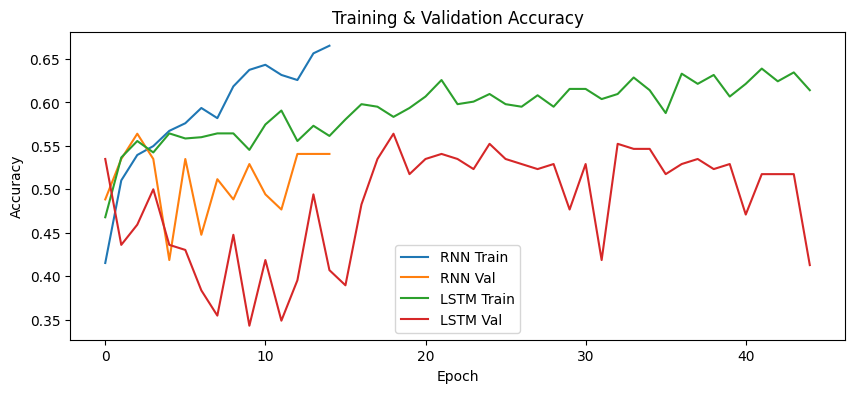

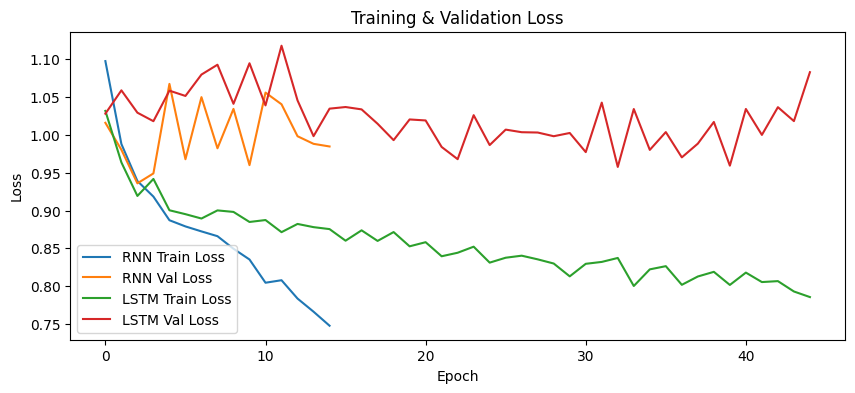

In [ ]:
import matplotlib.pyplot as plt

#Plot accuracy
plt.figure(figsize=(10,4))
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Plot Loss
plt.figure(figsize=(10,4))
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


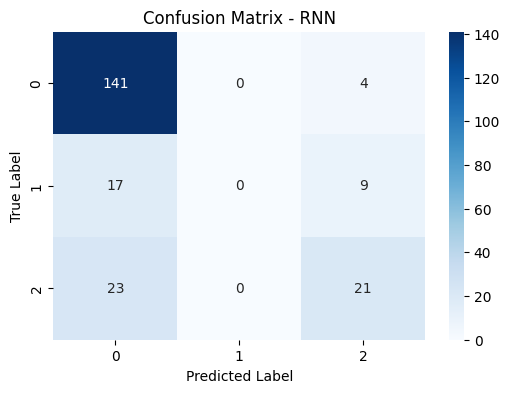

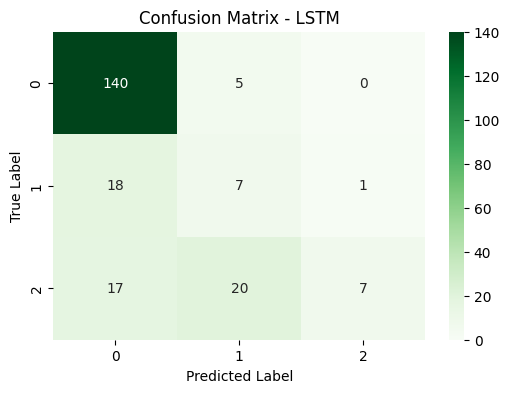

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Confusion Matrix RNN
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rnn, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Confusion Matrix LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lstm, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,603 (338.30 KB)

 Trainable params: 28,867 (112.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,736 (225.54 KB)

In [ ]:
model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,427 (1.48 MB)

 Trainable params: 129,475 (505.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 258,952 (1011.54 KB)

In [ ]:
model_lstm.layers[0].get_config()


{'name': 'lstm',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'return_sequences': True,
 'return_state': False,
 'go_backwards': False,
 'stateful': False,
 'unroll': False,
 'zero_output_for_mask': False,
 'units': 128,
 'activation': 'tanh',
 'recurrent_activation': 'sigmoid',
 'use_bias': True,
 'kernel_initializer': {'module': 'keras.initializers',
  'class_name': 'GlorotUniform',
  'config': {'seed': None},
  'registered_name': None},
 'recurrent_initializer': {'module': 'keras.initializers',
  'class_name': 'Orthogonal',
  'config': {'seed': None, 'gain': 1.0},
  'registered_name': None},
 'bias_initializer': {'module': 'keras.initializers',
  'class_name': 'Zeros',
  'config': {},
  'registered_name': None},
 'unit_forget_bias': True,
 'kernel_regularizer': None,
 'recurrent_regularizer': None,
 'bias_regularizer': None,
 'activity_regularizer': None,
 'kernel_constraint': None,
 'r